In [1]:
# =========================================================================
# PURPOSE
#   Grid-search the (p, q) lag combination of an Autoregressive
#   Distributed Lag (ADL) model for every pairing of an asset return
#   series with a structural news shock. The ADL model fitted at every
#   point of the grid is
#
#       r_t = c
#             + sum_{j=1}^{p} phi_j * r_{t-j}
#             + sum_{j=0}^{q} theta_j * news_{t-j}
#             + e_t,                          e_t ~ (0, sigma^2),
#
#   where r_t is the daily log-return of either the EU Allowance (EUA)
#   future or the S&P Global LargeMidCap PAB ESG index, and news_t is one
#   of the three structural shocks {Supply, Demand, Risk}.
#
#   For every (p, q) in the grid the script reports the AIC, the BIC and
#   the p-values of the highest-order own lag (X_lag p) and of the
#   highest-order news lag (News_lag q). These p-values diagnose whether
#   the marginal lag adds significant explanatory power on top of the
#   shorter specifications. All grids and significance tables are saved
#   into a single Excel workbook with one sheet per (asset x shock)
#   pairing, and AIC/BIC heatmaps are exported as PNG figures.
#
#   Pipeline (cell 1)
#     1. Load the price data, build daily log-returns and drop the
#        starting NaN row.
#     2. Loop over the six (asset, shock) combinations:
#          a. Build the lagged-design dataframe.
#          b. Fit OLS for every (p, q) with p in {1, ..., MAX_P} and
#             q in {0, ..., MAX_Q}.
#          c. Track the (p, q) that minimises AIC and the (p, q) that
#             minimises BIC.
#          d. Record the marginal-lag p-values for the significance
#             diagnostic.
#     3. Persist all detailed tables to GridSearch_Significance_Results.xlsx.
#     4. Print the summary of the best AIC and the best BIC model for
#        every combination, and produce one heatmap per criterion.
#
#   Pipeline (cell 2)
#     5. Re-estimate one specifically chosen (asset, shock, p, q) model
#        and print its full statsmodels summary.
#
#   External dependencies:
#       - Data.xlsx  (input data; sheet 'Tabelle1')
#       - xlsxwriter      (Excel-export engine for pandas)
# =========================================================================


[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

  X    : Return_EU Allowance EUA Futures (USD)
  News : News Supply Shock
 Optimal AIC model:  p = 6,  q = 10
 Optimal BIC model:  p = 1,  q = 0

  X    : Return_EU Allowance EUA Futures (USD)
  News : News Demand Shock
 Optimal AIC model:  p = 6,  q = 10
 Optimal BIC model:  p = 1,  q = 0

  X    : Return_EU Allowance EUA Futures (USD)
  News : News Risk Shock
 Optimal AIC model:  p = 6,  q = 0
 Optimal BIC model:  p = 1,  q = 0

  X    : Return_S&P Global LargeMidCap PAB ESG Index (USD)
  News : News Supply Shock
 Optimal AIC model:  p = 10,  q = 8
 Optimal BIC model:  p = 9,  q = 1

  X    : Return_S&P Global LargeMidCap PAB ESG Index (USD)
  News : News Demand Shock
 Optimal AIC model:  p = 9,  q = 10
 Optimal BIC model:  p = 9,  q = 0

  X    : Return_S&P Global LargeMidCap PAB ESG Index (USD)
  News : News Risk Shock
 Optimal AIC model:  p = 10,  q = 9
 Optimal BIC mode

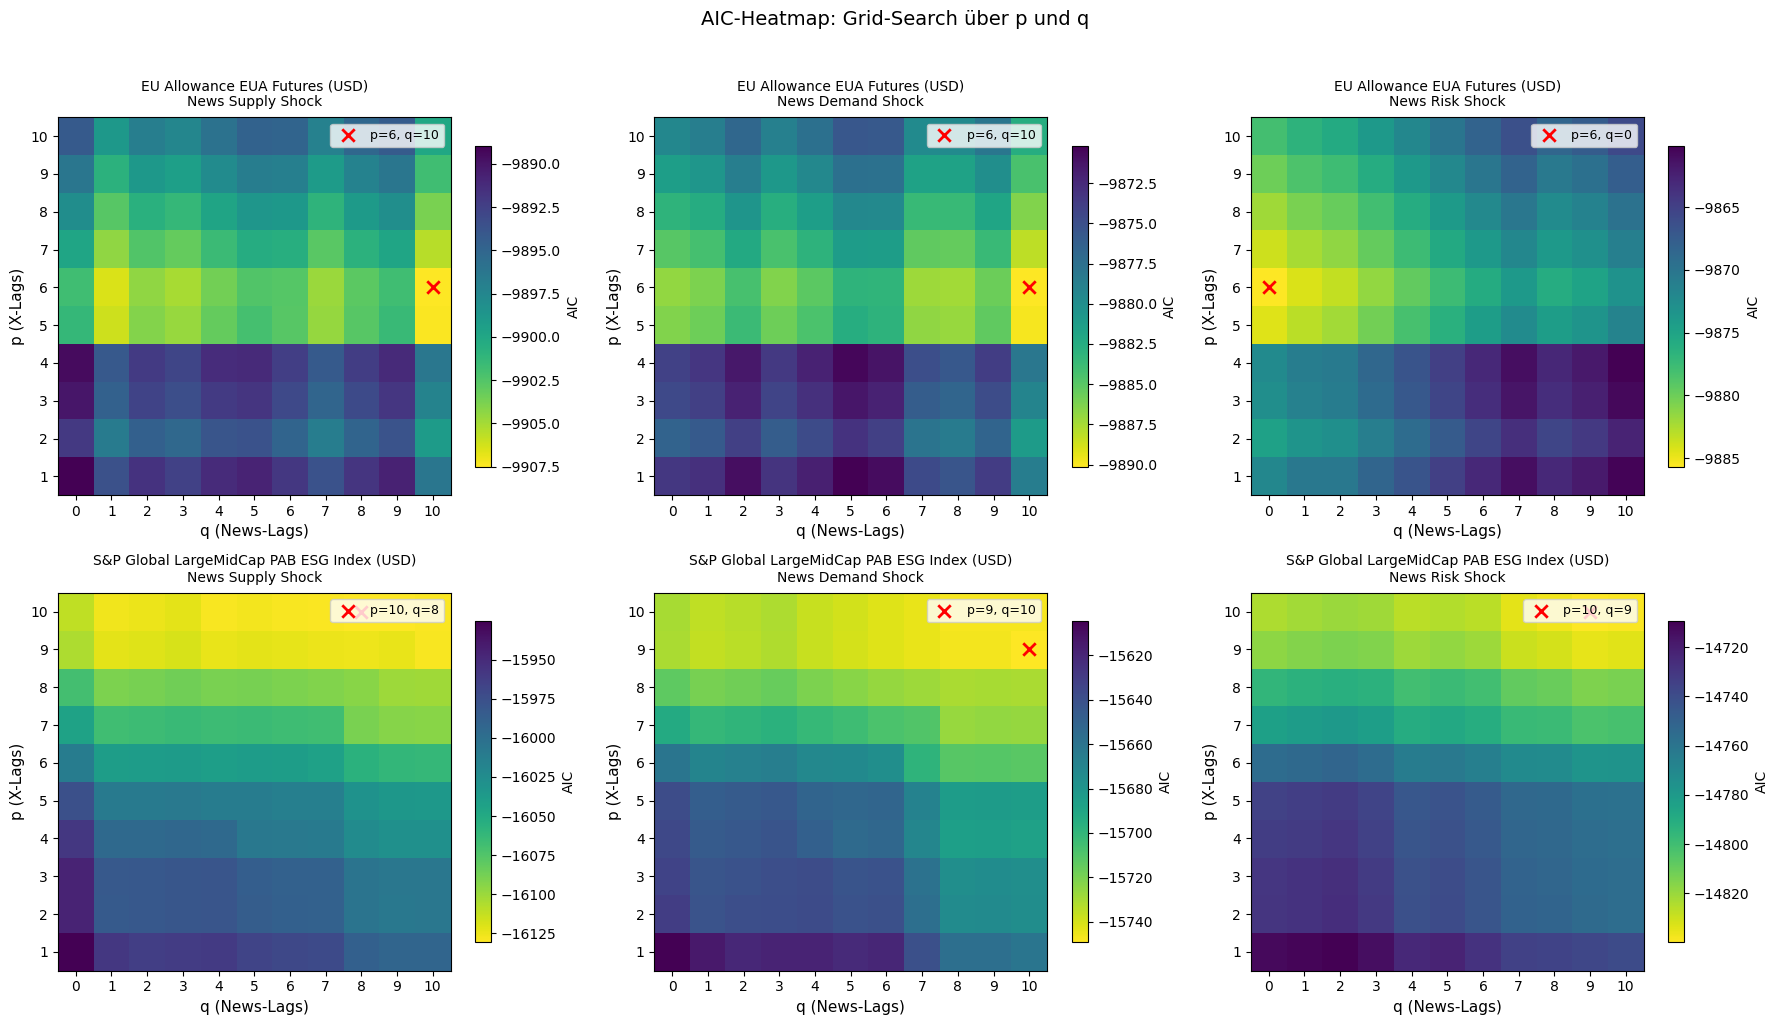

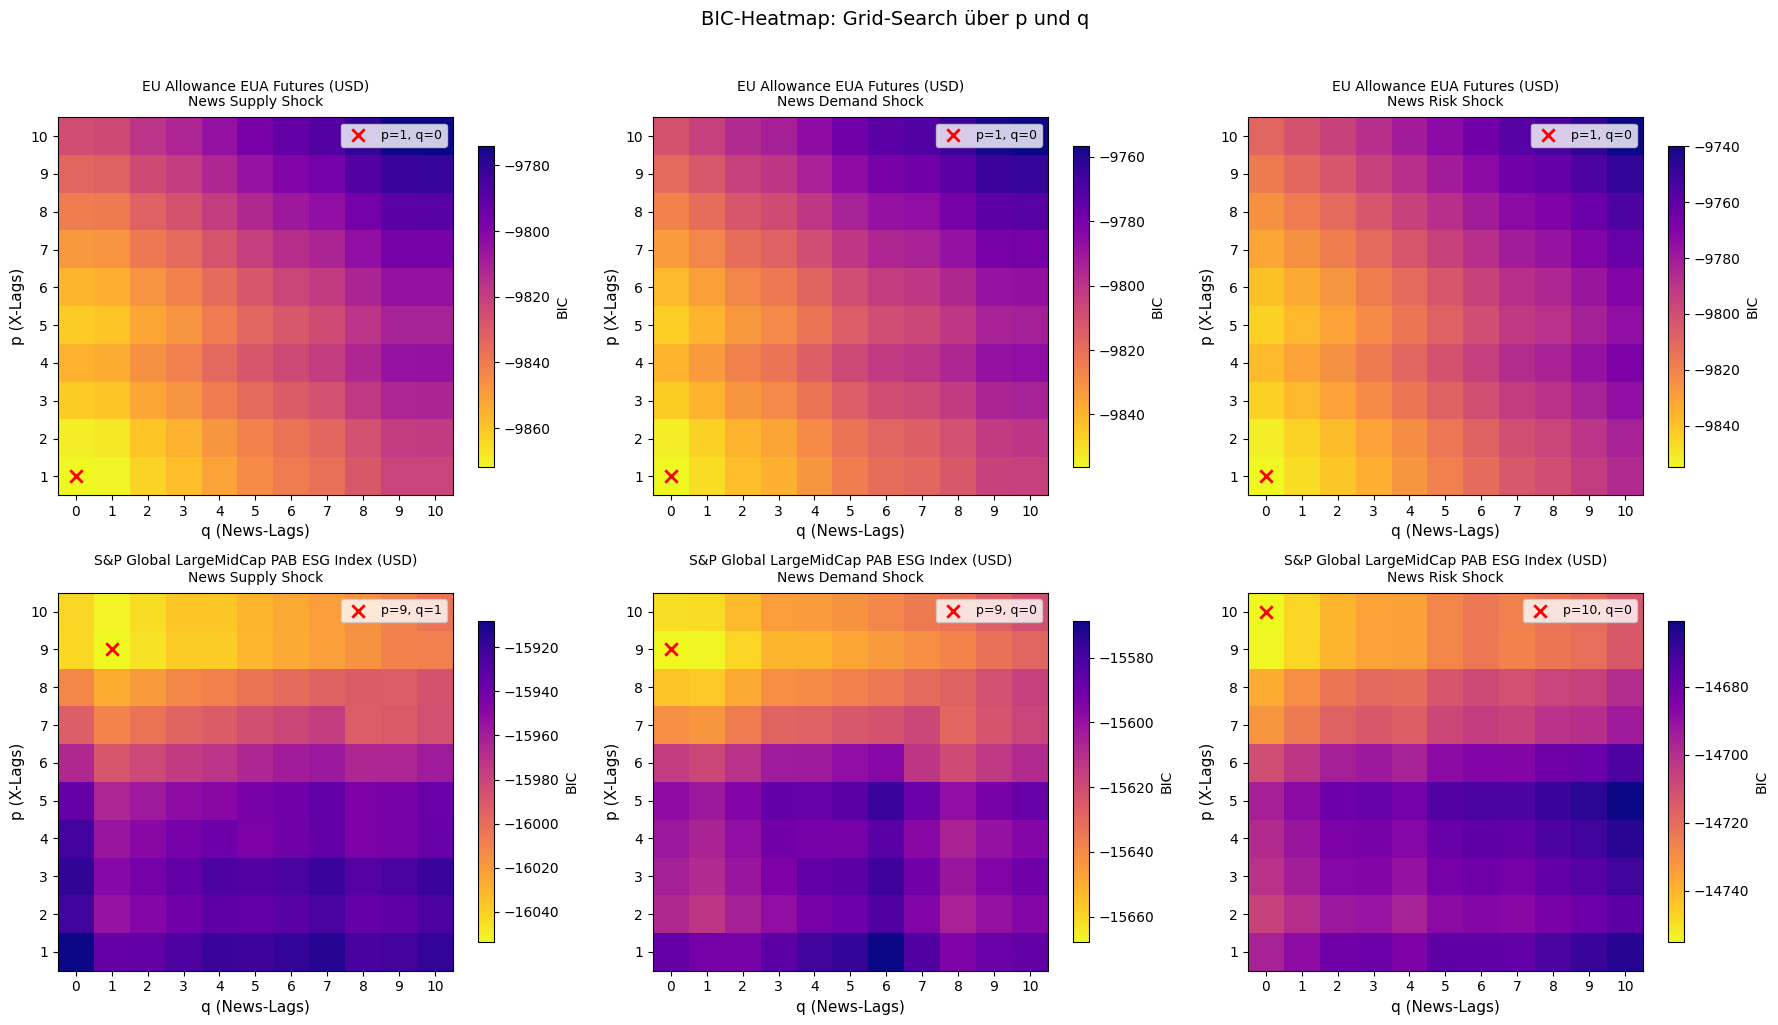

In [2]:
import sys
get_ipython().system('{sys.executable} -m pip install xlsxwriter')

import warnings
import numpy as np
import pandas as pd
from itertools import product
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller   # imported for completeness
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from Functions import prepare_data, run_ols

warnings.filterwarnings("ignore")

# -------------------------------------------------------------------------
# Load price data and build daily log-returns
# -------------------------------------------------------------------------
FILE = "/Users/johannesfelchner/Desktop/Code/Sections 3.3-3.4/Data.xlsx"
df   = pd.read_excel(FILE, sheet_name="Tabelle1", parse_dates=["Date"])
df   = df.sort_values("Date").reset_index(drop=True)

# Two endogenous price series in levels.
X_VARS = [
    "EU Allowance EUA Futures (USD)",
    "S&P Global LargeMidCap PAB ESG Index (USD)",
]

# Daily log-returns r_t = log(P_t) - log(P_{t-1}).
df_returns = df.copy()
for col in X_VARS:
    df_returns[f"Return_{col}"] = np.log(df[col]).diff()

X_VARS_RETURNS = [f"Return_{col}" for col in X_VARS]

# Drop the first row introduced by `.diff()`.
df_returns = df_returns.dropna(subset=X_VARS_RETURNS).reset_index(drop=True)

# Three structural news shocks to test against each return series.
NEWS_VARS = ["News Supply Shock", "News Demand Shock", "News Risk Shock"]

# Search grid: p in {1, ..., MAX_P}, q in {0, ..., MAX_Q}.
MAX_P = 10
MAX_Q = 10

# -------------------------------------------------------------------------
# Loop over the six (asset, shock) combinations
# -------------------------------------------------------------------------
all_results    = []
excel_filename = "GridSearch_Significance_Results.xlsx"
writer         = pd.ExcelWriter(excel_filename, engine='xlsxwriter')

for x_col, news_col in product(X_VARS_RETURNS, NEWS_VARS):

    # Build the design dataframe once (largest grid point).
    model_data = prepare_data(df_returns, x_col, news_col, MAX_P, MAX_Q)

    # Trackers for the best AIC and BIC models.
    best_aic = np.inf
    best_bic = np.inf
    best_p_aic = best_q_aic = None
    best_p_bic = best_q_bic = None
    best_res_aic = best_res_bic = None
    best_nobs = 0

    # Storage for the criterion grids and the per-grid significance row.
    aic_grid = np.full((MAX_P, MAX_Q + 1), np.nan)
    bic_grid = np.full((MAX_P, MAX_Q + 1), np.nan)
    significance_data = []

    # Inner double loop over (p, q).
    for p, q in product(range(1, MAX_P + 1), range(0, MAX_Q + 1)):
        aic, bic, nobs, res = run_ols(model_data, x_col, p, q)
        aic_grid[p - 1, q] = aic
        bic_grid[p - 1, q] = bic

        # Significance diagnostic: read the p-value of the highest-order
        # own lag (X_lag p) and of the highest-order news lag (News_lag q).
        # These are the only lags that disappear when the order is
        # decreased by one, so they pinpoint where the marginal value
        # of an extra lag becomes statistically negligible.
        pval_x_max    = np.nan
        pval_news_max = np.nan
        if res is not None:
            pvals    = res.pvalues
            var_x    = f"X_lag{p}"
            if var_x in pvals:
                pval_x_max = pvals[var_x]
            var_news = f"News_lag{q}"
            if var_news in pvals:
                pval_news_max = pvals[var_news]

        significance_data.append({
            "p (X Lags)":                     p,
            "q (News Lags)":                  q,
            "AIC":                            round(aic, 4) if aic != np.inf else np.nan,
            "BIC":                            round(bic, 4) if bic != np.inf else np.nan,
            "p-Value max X-Lag":              pval_x_max,
            "p-Value max News-Lag":           pval_news_max,
            "Max X-Lag Signifikant (<5%)":    "Yes" if pval_x_max    < 0.05 else "No",
            "Max News-Lag Signifikant (<5%)": "Yes" if pval_news_max < 0.05 else "No",
        })

        # Track best AIC.
        if aic < best_aic:
            best_aic     = aic
            best_p_aic   = p
            best_q_aic   = q
            best_res_aic = res
            best_nobs    = nobs

        # Track best BIC.
        if bic < best_bic:
            best_bic     = bic
            best_p_bic   = p
            best_q_bic   = q
            best_res_bic = res

    # Persist this combination's grid table to its own Excel sheet.
    df_sig = pd.DataFrame(significance_data)
    sheet_name = (
        f"{x_col.replace('Return_', '')[:15]}_"
        f"{news_col.replace('News ', '')[:10]}"
    )
    df_sig.to_excel(writer, sheet_name=sheet_name, index=False)

    # Collect the summary record for the post-loop reports.
    all_results.append({
        "X":              x_col,
        "News":           news_col,
        "best_p_aic":     best_p_aic,
        "best_q_aic":     best_q_aic,
        "best_AIC":       round(best_aic, 4),
        "best_model_aic": best_res_aic,
        "best_p_bic":     best_p_bic,
        "best_q_bic":     best_q_bic,
        "best_BIC":       round(best_bic, 4),
        "best_model_bic": best_res_bic,
        "nobs":           best_nobs,
        "aic_grid":       aic_grid,
        "bic_grid":       bic_grid,
        "df_sig":         df_sig,
    })

    print(f"\n  X    : {x_col}")
    print(f"  News : {news_col}")
    print(f" Optimal AIC model:  p = {best_p_aic},  q = {best_q_aic}")
    print(f" Optimal BIC model:  p = {best_p_bic},  q = {best_q_bic}")

writer.close()
# -------------------------------------------------------------------------
# Console summary of the best AIC / BIC models
# -------------------------------------------------------------------------
for criterion in ["AIC", "BIC"]:
    print("\n\n" + "=" * 70)
    print(f"Detailed results - top models ({criterion})")
    print("=" * 70)
    for r in all_results:
        print(f"\n{'─' * 70}")
        print(f"  X    : {r['X']}")
        print(f"  News : {r['News']}")
        key_p   = f"best_p_{criterion.lower()}"
        key_q   = f"best_q_{criterion.lower()}"
        key_val = f"best_{criterion}"
        key_mod = f"best_model_{criterion.lower()}"
        print(f"  Optimal model ({criterion}): p = {r[key_p]}, q = {r[key_q]}")
        print(f"  {criterion} = {r[key_val]:.4f}   |   Observations = {r['nobs']}")
        print()
        if r[key_mod] is not None:
            print(r[key_mod].summary())

# -------------------------------------------------------------------------
# AIC and BIC heatmaps over the (p, q) grid
# -------------------------------------------------------------------------
for criterion, grid_key, cmap in [
    ("AIC", "aic_grid", "viridis_r"),
    ("BIC", "bic_grid", "plasma_r"),
]:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for ax, r in zip(axes, all_results):
        grid   = r[grid_key]
        best_p = r[f"best_p_{criterion.lower()}"]
        best_q = r[f"best_q_{criterion.lower()}"]

        # Display the grid as a heatmap. `extent` is set so that the
        # axis ticks fall on the integer (p, q) values.
        im = ax.imshow(
            grid,
            aspect="auto",
            origin="lower",
            cmap=cmap,
            interpolation="nearest",
            extent=[-0.5, MAX_Q + 0.5, 0.5, MAX_P + 0.5],
        )

        # Highlight the criterion's argmin with a red cross.
        ax.scatter(
            best_q, best_p,
            color="red", s=80, zorder=5, marker="x", linewidths=2,
            label=f"p={best_p}, q={best_q}",
        )

        # Cosmetic axis tweaks.
        ax.set_xlabel("q (News-Lags)", fontsize=11)
        ax.set_ylabel("p (X-Lags)",    fontsize=11)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(integer=True))
        ax.set_title(
            f"{r['X'].replace('Return_', '')}\n{r['News']}",
            fontsize=10, pad=8,
        )
        ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
        ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
        ax.legend(fontsize=9, loc="upper right")
        plt.colorbar(im, ax=ax, label=criterion, shrink=0.85)

    plt.suptitle(
        f"{criterion}-Heatmap: Grid-Search über p und q",
        fontsize=14, y=1.02,
    )
    plt.tight_layout()
    plt.savefig(f"{criterion.lower()}_heatmap_grid.png",
                dpi=150, bbox_inches="tight")
    plt.show()

In [3]:
# -------------------------------------------------------------------------
# Targeted analysis for the specification chosen for the final paper
# -------------------------------------------------------------------------
MY_X    = "Return_S&P Global LargeMidCap PAB ESG Index (USD)"
MY_NEWS = "News Risk Shock"
MY_P    = 10
MY_Q    = 0

print("\n" + "=" * 80)
print(f"Targeted analysis for: {MY_X}")
print(f"Shock: {MY_NEWS} | Choosen: p={MY_P}, q={MY_Q}")
print("=" * 80)

# Re-prepare the data with the same grid bounds used above so the
# index alignment is identical to the grid-search run.
target_data = prepare_data(df_returns, MY_X, MY_NEWS, MAX_P, MAX_Q)

# Fit the chosen (p, q) and print the full statsmodels summary.
_, _, nobs_final, final_model = run_ols(target_data, MY_X, MY_P, MY_Q)

print(final_model.summary())
print(f"\nObservations used (nobs): {nobs_final}")
print("=" * 80)
print(f"AIC: {final_model.aic:.2f}")
print(f"BIC: {final_model.bic:.2f}")


Targeted analysis for: Return_S&P Global LargeMidCap PAB ESG Index (USD)
Shock: News Risk Shock | Choosen: p=10, q=0
                                            OLS Regression Results                                           
Dep. Variable:     Return_S&P Global LargeMidCap PAB ESG Index (USD)   R-squared:                       0.059
Model:                                                           OLS   Adj. R-squared:                  0.054
Method:                                                Least Squares   F-statistic:                     12.77
Date:                                               Fri, 08 May 2026   Prob (F-statistic):           8.35e-24
Time:                                                       15:56:44   Log-Likelihood:                 7423.9
No. Observations:                                               2268   AIC:                        -1.482e+04
Df Residuals:                                                   2256   BIC:                        -1.476e+04
Df